In [40]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np


import pyro
import pyro.contrib.gp as gp
import pyro.distributions as dist

from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


smoke_test = "CI" in os.environ  # ignore; used to check code integrity in the Pyro repo
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(0)
torch.set_default_tensor_type(torch.DoubleTensor)

/home/oliverholland/repos/astar-island/.venv/lib/python3.13/site-packages/torch/__init__.py:1310: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


In [41]:
# note that this helper function does three different things:
# (i) plots the observed data;
# (ii) plots the predictions from the learned GP after conditioning on data;
# (iii) plots samples from the GP prior (with no conditioning on observed data)


def plot(
    plot_observed_data=False,
    plot_predictions=False,
    n_prior_samples=0,
    model=None,
    kernel=None,
    n_test=500,
    ax=None,
):

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    if plot_observed_data:
        ax.plot(X.numpy(), y.numpy(), "kx")
    if plot_predictions:
        Xtest = torch.linspace(-0.5, 5.5, n_test)  # test inputs
        # compute predictive mean and variance
        with torch.no_grad():
            if type(model) == gp.models.VariationalSparseGP:
                mean, cov = model(Xtest, full_cov=True)
            else:
                mean, cov = model(Xtest, full_cov=True, noiseless=False)
        sd = cov.diag().sqrt()  # standard deviation at each input point x
        ax.plot(Xtest.numpy(), mean.numpy(), "r", lw=2)  # plot the mean
        ax.fill_between(
            Xtest.numpy(),  # plot the two-sigma uncertainty about the mean
            (mean - 2.0 * sd).numpy(),
            (mean + 2.0 * sd).numpy(),
            color="C0",
            alpha=0.3,
        )
    if n_prior_samples > 0:  # plot samples from the GP prior
        Xtest = torch.linspace(-0.5, 5.5, n_test)  # test inputs
        noise = (
            model.noise
            if type(model) != gp.models.VariationalSparseGP
            else model.likelihood.variance
        )
        cov = kernel.forward(Xtest) + noise.expand(n_test).diag()
        samples = dist.MultivariateNormal(
            torch.zeros(n_test), covariance_matrix=cov
        ).sample(sample_shape=(n_prior_samples,))
        ax.plot(Xtest.numpy(), samples.numpy().T, lw=2, alpha=0.4)

    ax.set_xlim(-0.5, 5.5)

In [85]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


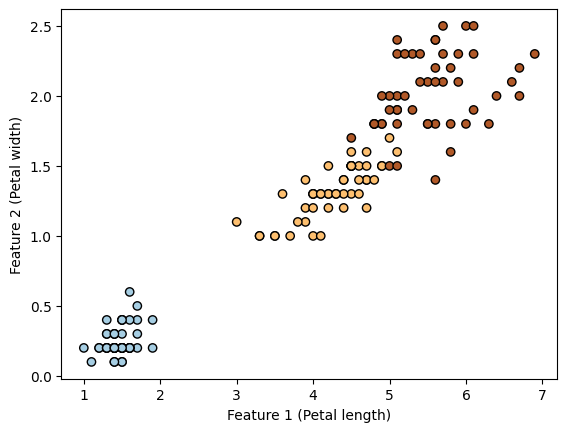

In [87]:

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors=(0, 0, 0))
plt.xlabel("Feature 1 (Petal length)")
_ = plt.ylabel("Feature 2 (Petal width)")



In [88]:
kernel = gp.kernels.RBF(input_dim=2)
pyro.clear_param_store()
likelihood = gp.likelihoods.MultiClass(num_classes=3)
# Important -- we need to add latent_shape argument here to the number of classes we have in the data
model = gp.models.VariationalGP(
    X,
    y,
    kernel,
    likelihood=likelihood,
    whiten=True,
    jitter=1e-03,
    latent_shape=torch.Size([3]),
)
num_steps = 1000
loss = gp.util.train(model, num_steps=num_steps)

In [89]:
# let's plot the loss curve after 2000 steps of training
def plot_loss(loss):
    plt.plot(loss)
    plt.xlabel("Iterations")
    _ = plt.ylabel("Loss")  # supress output text

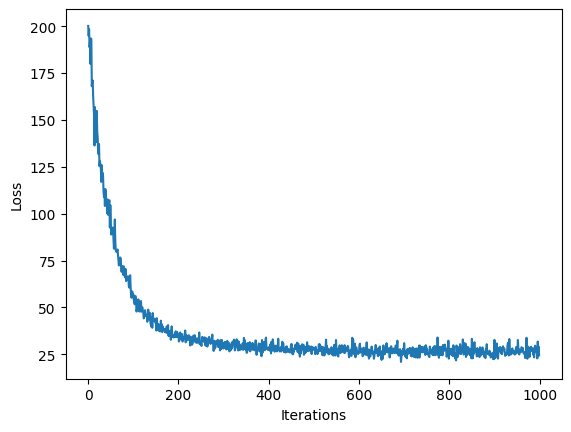

In [90]:
plot_loss(loss)

In [91]:
mean, var = model(X)
y_hat = model.likelihood(mean, var)

print(f"Accuracy: {(y_hat==y).sum()*100/(len(y)) :0.2f}%")

Accuracy: 95.33%


In [92]:
xs = torch.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, steps=100)
ys = torch.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, steps=100)
xx, yy = torch.meshgrid(xs, ys, indexing="xy")

with torch.no_grad():
    mean, var = model(torch.vstack((xx.ravel(), yy.ravel())).t())
    Z = model.likelihood(mean, var)

In [93]:
def plot_pred_2d(arr, xx, yy, contour=False, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots()
    image = ax.imshow(
        arr,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect="equal",
        origin="lower",
        cmap=plt.cm.PuOr_r,
    )
    if contour:
        contours = ax.contour(
            xx,
            yy,
            torch.sigmoid(mean).reshape(xx.shape),
            levels=[0.5],
            linewidths=2,
            colors=["k"],
        )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    ax.get_figure().colorbar(image, cax=cax)
    if title:
        ax.set_title(title)

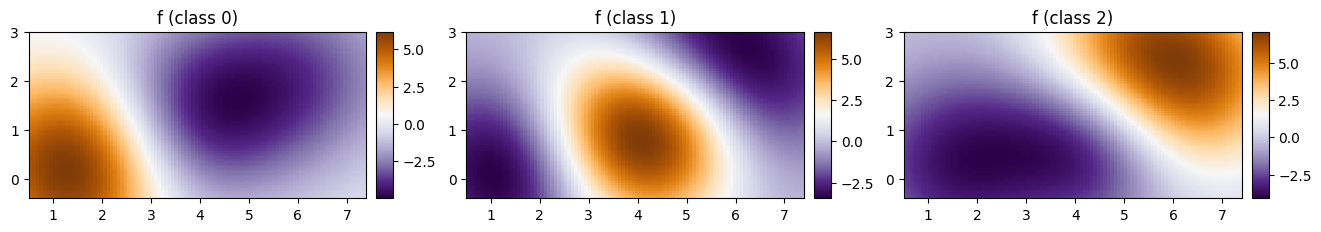

In [94]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
for cl in [0, 1, 2]:
    plot_pred_2d(
        mean[cl, :].reshape(xx.shape), xx, yy, ax=ax[cl], title=f"f (class {cl})"
    )

In [95]:
p_class = torch.nn.functional.softmax(mean, dim=0)

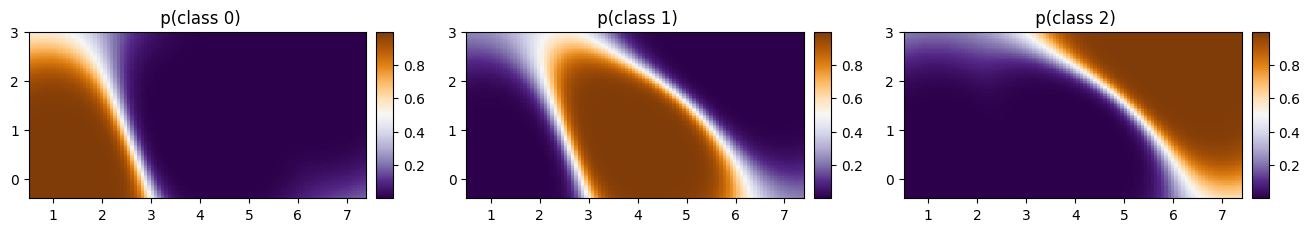

In [96]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
for cl in [0, 1, 2]:
    plot_pred_2d(
        p_class[cl, :].reshape(xx.shape), xx, yy, ax=ax[cl], title=f" p(class {cl})"
    )



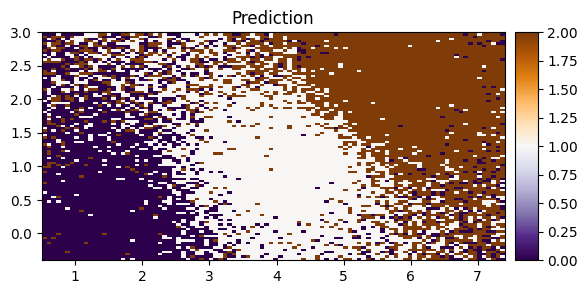

In [97]:
plot_pred_2d(Z.reshape(xx.shape), xx, yy, title="Prediction")

In [102]:

def hmm_model(data, data_dim, hidden_dim=10):
    print(f"Running for {len(data)} time steps")
    # Sample global matrices wrt a Jeffreys prior.
    with pyro.plate("hidden_state", hidden_dim):
        transition = pyro.sample("transition", dist.Dirichlet(0.5 * torch.ones(hidden_dim)))
        emission = pyro.sample("emission", dist.Dirichlet(0.5 * torch.ones(data_dim)))

    x = 0  # initial state
    for t, y in enumerate(data):
        x = pyro.sample(f"x_{t}", dist.Categorical(transition[x]),
                        infer={"enumerate": "parallel"})
        pyro.sample(f"  y_{t}", dist.Categorical(emission[x]), obs=y)
        print(f"  x_{t}.shape = {x.shape}")

In [103]:
data = data.type(torch.float32)

In [106]:
X = data[0]
y = data[-1]

In [108]:
kernel = gp.kernels.RBF(input_dim=40)
pyro.clear_param_store()
likelihood = gp.likelihoods.MultiClass(num_classes=num_classes)
# Important -- we need to add latent_shape argument here to the number of classes we have in the data
model = gp.models.VariationalGP(
    X,
    y,
    kernel,
    likelihood=likelihood,
    whiten=True,
    jitter=1e-03,
    latent_shape=torch.Size([num_classes]),
)
train_steps = 1000
loss = gp.util.train(model, num_steps=train_steps)

In [110]:
y

tensor([[5., 0., 1.,  ..., 5., 0., 0.],
        [5., 3., 0.,  ..., 1., 2., 0.],
        [3., 5., 3.,  ..., 4., 2., 0.],
        ...,
        [3., 4., 5.,  ..., 4., 0., 0.],
        [4., 1., 1.,  ..., 5., 3., 1.],
        [2., 3., 1.,  ..., 2., 2., 3.]], dtype=torch.float32)

In [112]:
mean, var = model(X)

In [ ]:
mean

torch.Size([6, 40])

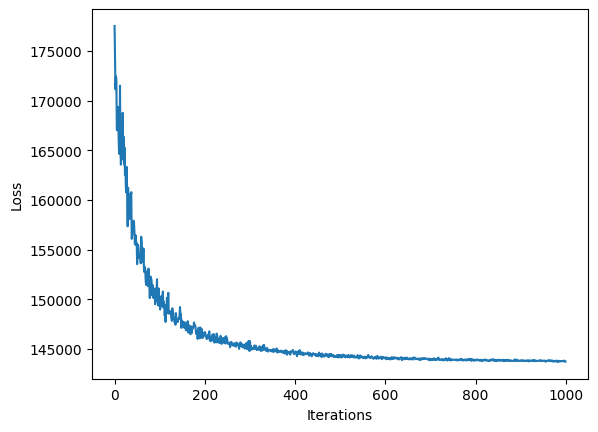

In [79]:
plot_loss(loss)

In [45]:
# only take petal length and petal width
X = torch.from_numpy(
    df[df.columns[2:4]].values.astype("float64"),
)
df["species"] = df["species"].astype("category")
# encode the species as 0, 1, 2
y = torch.from_numpy(df["species"].cat.codes.values.copy())